# Snapscan segmentation example

This notebook processes ENVI hyperspectral cubes produced by the snapscan camera in the NPEC greenhouse.

For each `.hdr` file in the selected folder it:

1. loads the cube and wavelength metadata;
2. smooths each pixel spectrum with a 1D Gaussian filter;
3. creates an initial plant candidate mask by thresholding the band closest to 750 nm;
4. refines that mask with wavelength-window ratios around 650, 750, and 850 nm;
5. removes small connected components, extracts plant-only spectra, and summarizes them;
6. visualizes the final mask and exports mean and standard-deviation spectra to CSV.

The notebook also includes interactive inspection views for the masked ratio image and individual pixel spectra.

In [1]:
import os
import glob
import numpy as np
import spectral
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage

In [ ]:
# Folder containing all .hdr files to process
folder = "test_plant"

## Segmentation functions

The segmentation implemented below runs in three main stages, followed by a small-object cleanup step:

1. **Spectral smoothing**: each pixel spectrum is smoothed along the spectral axis with a 1D Gaussian filter to reduce band-to-band noise before thresholding.
2. **Initial NIR mask**: the smoothed cube is thresholded at the band closest to **750 nm**. Pixels with reflectance below `0.1` at that wavelength are removed.
3. **Tri-band ratio cleanup**: three wavelength windows are summed around **650 nm (red)**, **750 nm (NIR)**, and **850 nm (SWIR)**. The candidate mask is then filtered with two ratio tests:

   - `SWIR / NIR <= 1.5` to reject background, steel, and other non-plant materials
   - `NIR / Red >= 2.0` to retain pixels with a strong plant-like red-edge response

After the ratio tests, the mask is cleaned with binary opening and closing, then connected components smaller than 100 pixels are removed. The remaining mask is used to zero out background pixels and extract plant-only spectra for averaging and export.

A false-color diagnostic view and two interactive viewers are included so you can inspect both the final mask and the spectral behaviour of selected pixels.

In [14]:

# Helper functions
def _safe_band_range(start, end, n_bands):
    """Clamp a band slice to valid cube bounds."""
    start = max(0, min(start, n_bands - 1))
    end = max(start + 1, min(end, n_bands))
    return start, end

def _parse_wavelengths(wavelengths):
    """Convert wavelength metadata into a numeric NumPy array when possible."""
    if isinstance(wavelengths, str):
        wavelengths = [w.strip() for w in wavelengths.strip("{}").split(",")]
    if wavelengths is None:
        return None
    try:
        return np.array([float(w) for w in wavelengths], dtype=np.float32)
    except Exception:
        return None

def _nearest_wavelength_index(wavelengths_nm, target_nm, n_bands, default_idx):
    """Find the band index closest to a target wavelength."""
    if wavelengths_nm is None or len(wavelengths_nm) != n_bands:
        return max(0, min(default_idx, n_bands - 1))
    return int(np.argmin(np.abs(wavelengths_nm - target_nm)))

def _band_window_sum(cube, wavelengths_nm, target_nm, n_bands, default_idx, window_nm=20.0):
    """Sum all bands within ±(window_nm/2) nm of target_nm.

    When wavelength metadata is unavailable, falls back to summing 7 bands
    centred on default_idx (~20 nm at typical camera spacing).
    """
    if wavelengths_nm is not None and len(wavelengths_nm) == n_bands:
        half = window_nm / 2.0
        indices = np.where(np.abs(wavelengths_nm - target_nm) <= half)[0]
        if len(indices) > 0:
            return np.sum(cube[:, :, indices[0]:indices[-1] + 1], axis=2)
    # Fallback: 7-band window (~20 nm at ~3 nm/band spacing).
    start, end = _safe_band_range(default_idx - 3, default_idx + 4, n_bands)
    return np.sum(cube[:, :, start:end], axis=2)

def _keep_largest_component(mask):
    """Keep only the largest connected foreground region in a binary mask."""
    labeled_mask, num_features = scipy.ndimage.label(mask)
    if num_features == 0:
        return mask
    sizes = np.bincount(labeled_mask.ravel())
    sizes[0] = 0
    largest_label = np.argmax(sizes)
    return labeled_mask == largest_label

def smooth_spectra_cube(data, sigma=1.0):
    """Step 1: Smooth each pixel spectrum with a 1D Gaussian filter."""
    cube = np.asarray(data, dtype=np.float32)
    if cube.ndim != 3:
        raise ValueError(
            f"Expected a 3D cube (rows, cols, bands), got shape {cube.shape}"
        )
    return scipy.ndimage.gaussian_filter1d(cube, sigma=sigma, axis=2, mode="nearest")

def apply_ir_threshold(
    cube_smooth, wavelengths=None, target_nm=750.0, threshold=0.1, default_idx=97
):
    """Step 2: Threshold an IR band and return the IR-masked cube plus mask."""
    cube_smooth = np.asarray(cube_smooth, dtype=np.float32)
    if cube_smooth.ndim != 3:
        raise ValueError(
            f"Expected a 3D cube (rows, cols, bands), got shape {cube_smooth.shape}"
        )
    n_bands = cube_smooth.shape[2]
    wavelengths_nm = _parse_wavelengths(wavelengths)
    nir_idx = _nearest_wavelength_index(wavelengths_nm, target_nm, n_bands, default_idx)
    nir_band = cube_smooth[:, :, nir_idx]
    ir_mask = nir_band >= threshold
    cube_ir_masked = cube_smooth.copy()
    cube_ir_masked[~ir_mask] = 0
    return cube_ir_masked, ir_mask

def apply_tri_band_cleanup(
    cube_ir_masked,
    ir_mask,
    wavelengths=None,
    red_nm=650.0,
    nir_nm=750.0,
    swir_nm=850.0,
    red_default_idx=55,
    nir_default_idx=97,
    swir_default_idx=113,
    swir_nir_max=1.5,
    nir_red_min=2.0,
):
    """Step 3: Remove non-plant pixels using two band-window ratio masks.

    Each band value is the sum of all channels within ±10 nm of the target
    wavelength, reducing single-band noise.

    Two ratios are combined:
      - swir / nir <= swir_nir_max  — rejects background and steel
      - nir / red  >= nir_red_min   — retains strong red-edge (plant) response
    """
    cube_ir_masked = np.asarray(cube_ir_masked, dtype=np.float32)
    if cube_ir_masked.ndim != 3:
        raise ValueError(
            f"Expected a 3D cube (rows, cols, bands), got shape {cube_ir_masked.shape}"
        )

    n_bands = cube_ir_masked.shape[2]
    wavelengths_nm = _parse_wavelengths(wavelengths)
    red_band  = _band_window_sum(cube_ir_masked, wavelengths_nm, red_nm,  n_bands, red_default_idx)
    nir_band  = _band_window_sum(cube_ir_masked, wavelengths_nm, nir_nm,  n_bands, nir_default_idx)
    swir_band = _band_window_sum(cube_ir_masked, wavelengths_nm, swir_nm, n_bands, swir_default_idx)

    swir_nir = swir_band / (nir_band + 1e-8)
    nir_red  = nir_band  / (red_band  + 1e-8)

    nir_red_img = np.full(nir_red.shape, np.nan, dtype=np.float32)
    nir_red_img[ir_mask] = nir_red[ir_mask]

    # Keep pixels that pass both ratio tests.
    mask = ir_mask & (swir_nir <= swir_nir_max) & (nir_red >= nir_red_min)

    # Remove isolated speckle noise.
    mask = scipy.ndimage.binary_opening(mask, structure=np.ones((3, 3)))

    # binary_closing is disabled: it expands the mask into neighbouring pixels
    # that never passed the ratio checks, reintroducing background pixels and
    # merging gaps between leaves on complex branching plants.
    mask = scipy.ndimage.binary_closing(mask, structure=np.ones((5, 5)))

    labeled_mask, _ = scipy.ndimage.label(mask)
    sizes = np.bincount(labeled_mask.ravel())
    mask_clean = mask.copy()
    for i, size in enumerate(sizes):
        if i == 0:
            continue
        if size < 100:
            mask_clean[labeled_mask == i] = 0

    #mask_clean = _keep_largest_component(mask_clean)
    cube_vi_masked = cube_ir_masked.copy()
    cube_vi_masked[~mask_clean] = 0
    return cube_vi_masked, mask_clean, nir_red_img

def triband_image(data, wavelengths=None, red_nm=650.0, nir_nm=750.0, swir_nm=850.0,
                  red_default_idx=55, nir_default_idx=97, swir_default_idx=113):
    """Compute a smoothed nir/red ratio image from a hyperspectral cube.

    Each band value is the sum of all channels within ±10 nm of the target
    wavelength. High ratio values indicate strong red-edge response (plant material).
    """
    cube = np.asarray(data, dtype=np.float32)
    if cube.ndim != 3:
        raise ValueError(
            f"Expected a 3D cube (rows, cols, bands), got shape {cube.shape}"
        )
    cube_smooth = smooth_spectra_cube(cube)
    n_bands = cube.shape[2]
    wavelengths_nm = _parse_wavelengths(wavelengths)
    red = _band_window_sum(cube_smooth, wavelengths_nm, red_nm, n_bands, red_default_idx)
    nir = _band_window_sum(cube_smooth, wavelengths_nm, nir_nm, n_bands, nir_default_idx)
    return nir / (red + 1e-8)

def normalize_band(band):
    """Normalize a single spectral band to [0, 1] using 2nd and 98th percentiles."""
    p2, p98 = np.percentile(band, (2, 98))
    return np.clip((band - p2) / (p98 - p2 + 1e-8), 0, 1)

def false_color_image(cube, band_map=None):
    """Create a normalized false-color RGB image from a hyperspectral cube."""
    cube = np.asarray(cube, dtype=np.float32)
    if cube.ndim != 3:
        raise ValueError(
            f"Expected a 3D cube (rows, cols, bands), got shape {cube.shape}"
        )
    n_bands = cube.shape[2]
    default_bands = {"R": 105, "G": 60, "B": 35}
    selected_bands = default_bands if band_map is None else band_map
    band_idx = {key: min(value, n_bands - 1) for key, value in selected_bands.items()}
    rgb_image = np.dstack([
        normalize_band(cube[:, :, band_idx["R"]]),
        normalize_band(cube[:, :, band_idx["G"]]),
        normalize_band(cube[:, :, band_idx["B"]]),
    ])
    return rgb_image, band_idx


Found 1 file(s) to process.
  Processing Cube_corrected_whitereferenced.hdr ... done (192028 plant pixels).

Processed 1/1 image(s) successfully.


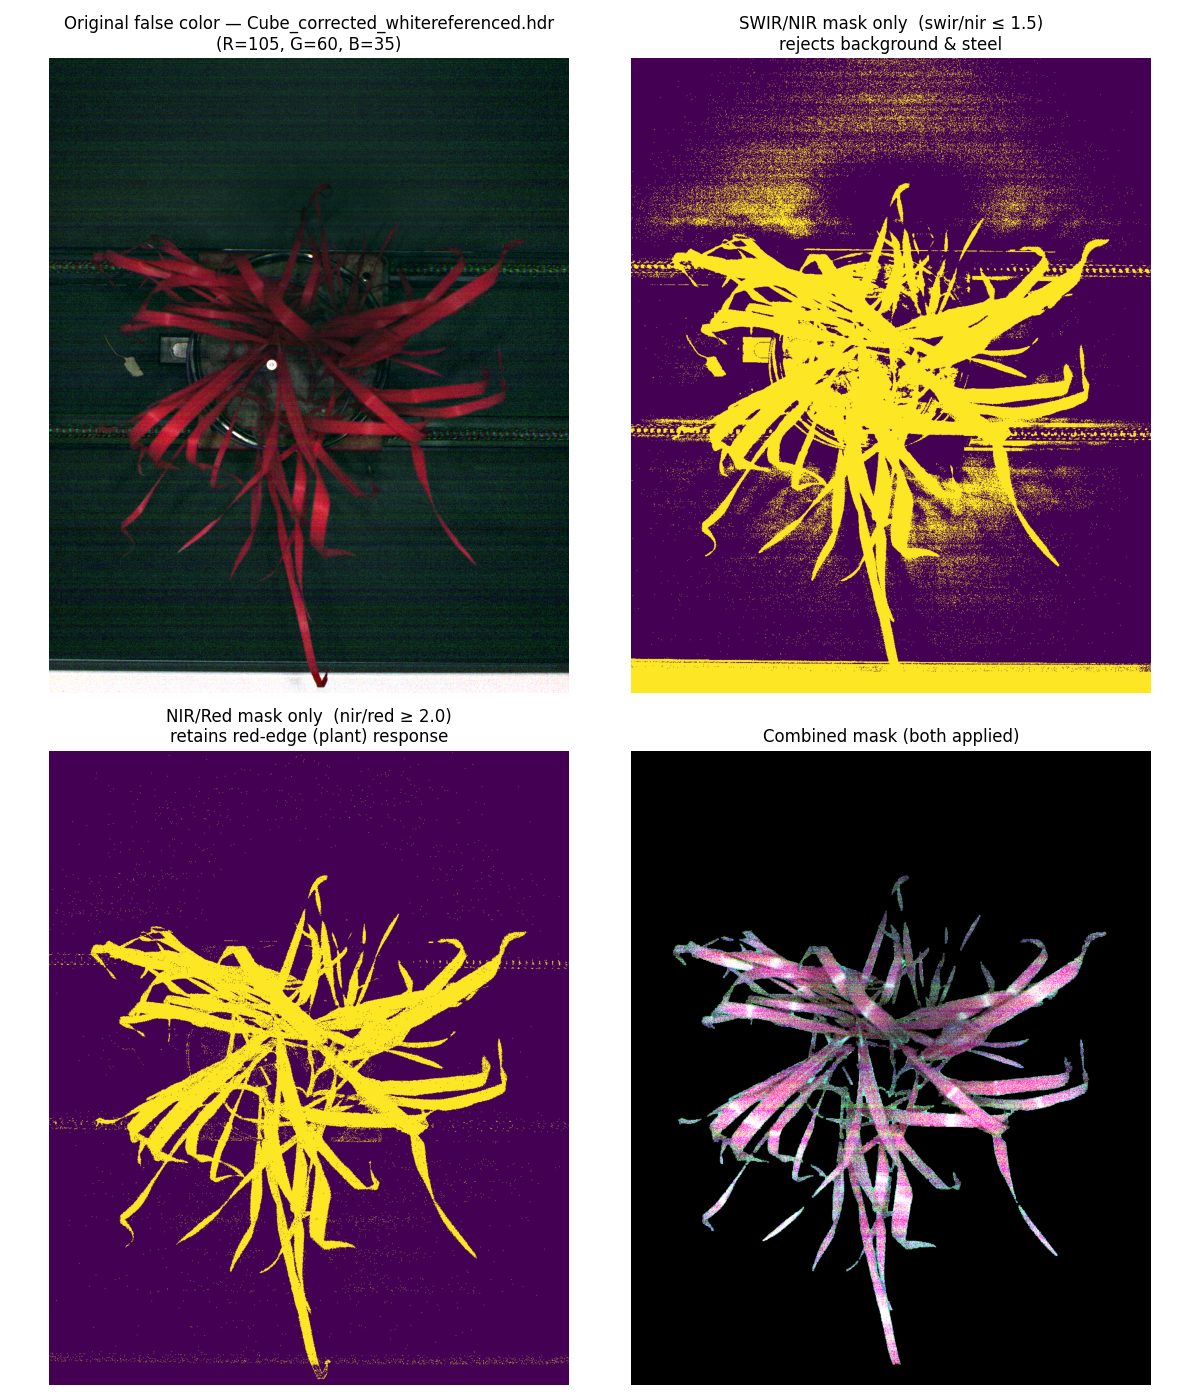

In [ ]:
# load files and apply mask, shows the output of the seperate segmentation steps for the last processed image at the end

hdr_files = sorted(glob.glob(os.path.join(folder, "*.hdr")))
if not hdr_files:
    raise FileNotFoundError(f"No .hdr files found in {folder}")

print(f"Found {len(hdr_files)} file(s) to process.")

results = []

for hdr_path in hdr_files:
    fname = os.path.basename(hdr_path)
    print(f"  Processing {fname} ...", end=" ", flush=True)

    img = spectral.open_image(hdr_path)
    data = img.load()
    cube = np.asarray(data, dtype=np.float32)

    wavelengths = img.metadata.get("wavelength", None)
    wavelengths_nm = _parse_wavelengths(wavelengths)
    n_bands = cube.shape[2]

    cube_smooth_img = smooth_spectra_cube(cube)
    cube_ir_masked_img, ir_mask_img = apply_ir_threshold(
        cube_smooth_img, wavelengths=wavelengths
    )
    cube_vi_masked_img, mask_2d, nir_red_img = apply_tri_band_cleanup(
        cube_ir_masked_img, ir_mask_img, wavelengths=wavelengths,
        swir_nir_max=1.5, nir_red_min=2.0
    )

    plant_pixels = cube_vi_masked_img[mask_2d, :]  # (n_plant_pixels, n_bands)
    n_plant_pixels = plant_pixels.shape[0]

    if n_plant_pixels == 0:
        print("WARNING: no plant pixels found, skipping.")
        continue

    # Clip to valid reflectance range before statistics — noisy edge bands
    # can contain inf/nan which cause overflow in np.std.
    plant_pixels = np.clip(plant_pixels, 0.0, 1.0)

    results.append({
        "filename": fname,
        "n_plant_pixels": n_plant_pixels,
        "avg_spectra": np.mean(plant_pixels, axis=0),
        "std_spectra": np.std(plant_pixels, axis=0),
    })
    print(f"done ({n_plant_pixels} plant pixels).")

print(f"\nProcessed {len(results)}/{len(hdr_files)} image(s) successfully.")

# --- Diagnostic 2x2 for the last processed image ---
_red  = _band_window_sum(cube_ir_masked_img, wavelengths_nm, 650.0, n_bands, 55)
_nir  = _band_window_sum(cube_ir_masked_img, wavelengths_nm, 750.0, n_bands, 97)
_swir = _band_window_sum(cube_ir_masked_img, wavelengths_nm, 850.0, n_bands, 113)
swir_nir_mask = ir_mask_img & ((_swir / (_nir + 1e-8)) <= 1.5)
nir_red_mask  = ir_mask_img & ((_nir  / (_red + 1e-8)) >= 2.0)

false_color_original, band_idx = false_color_image(cube)
fc_combined = false_color_image(cube_vi_masked_img)[0]

fig, axes = plt.subplots(2, 2, figsize=(12, 14))
axes[0, 0].imshow(np.flipud(false_color_original))
axes[0, 0].set_title(f"Original false color — {os.path.basename(hdr_path)}\n(R={band_idx['R']}, G={band_idx['G']}, B={band_idx['B']})")
axes[0, 0].axis("off")
axes[0, 1].imshow(np.flipud(swir_nir_mask))
axes[0, 1].set_title("SWIR/NIR mask only  (swir/nir ≤ 1.5)\nrejects background & steel")
axes[0, 1].axis("off")
axes[1, 0].imshow(np.flipud(nir_red_mask))
axes[1, 0].set_title("NIR/Red mask only  (nir/red ≥ 2.0)\nretains red-edge (plant) response")
axes[1, 0].axis("off")
axes[1, 1].imshow(np.flipud(fc_combined))
axes[1, 1].set_title("Combined mask (both applied)")
axes[1, 1].axis("off")
plt.tight_layout()
plt.show()


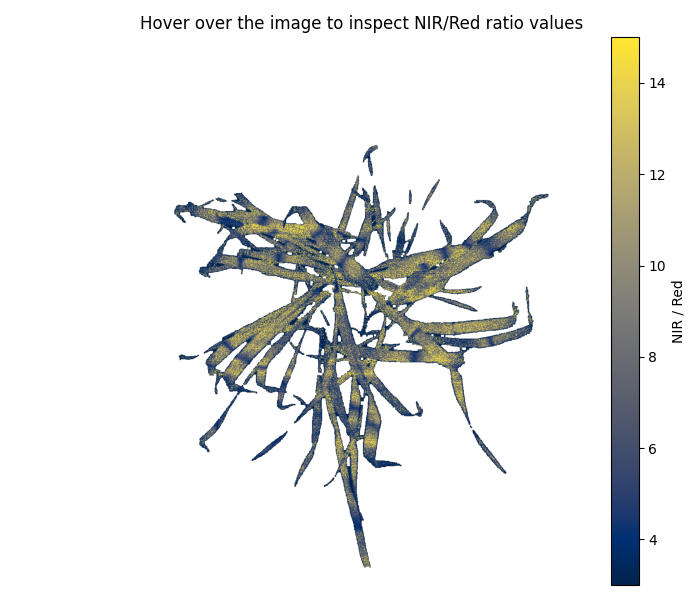

In [16]:

# Visualize NIR/Red ratio from the masked cube and inspect values by hovering
%matplotlib widget

if "cube_vi_masked_img" not in globals():
    raise NameError("`cube_vi_masked_img` is not available. Run the load cell first.")

vi_display_img_raw = triband_image(cube_vi_masked_img, wavelengths=wavelengths)
vi_display_img_raw[~mask_2d] = np.nan
display_img = np.flipud(vi_display_img_raw)

fig, ax = plt.subplots(figsize=(7, 6))
fig.canvas.header_visible = False
image_artist = ax.imshow(display_img, cmap="cividis", vmin=3.0, vmax=15.0)
marker, = ax.plot([], [], "wo", markersize=5, markeredgecolor="black")
title = ax.set_title("Hover over the image to inspect NIR/Red ratio values")
ax.axis("off")
fig.colorbar(image_artist, ax=ax, label="NIR / Red", fraction=0.046, pad=0.04)

def on_hover(event):
    if event.inaxes != ax or event.xdata is None or event.ydata is None:
        return

    col = int(np.clip(round(event.xdata), 0, display_img.shape[1] - 1))
    display_row = int(np.clip(round(event.ydata), 0, display_img.shape[0] - 1))
    row = display_img.shape[0] - 1 - display_row
    vi_value = vi_display_img_raw[row, col]

    marker.set_data([col], [display_row])
    if np.isfinite(vi_value):
        title.set_text(f"NIR/Red at row={row}, col={col}: {vi_value:.3f}")
    else:
        title.set_text(f"NIR/Red at row={row}, col={col}: masked")
    fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect("motion_notify_event", on_hover)
plt.tight_layout()
plt.show()


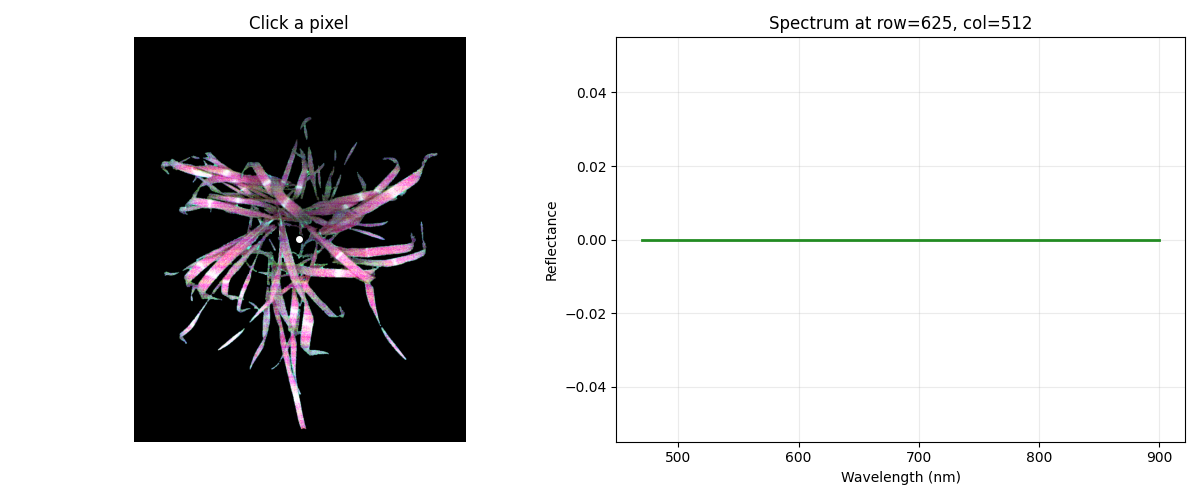

In [17]:
%matplotlib widget

if "cube_vi_masked_img" not in globals():
    raise NameError("`cube_vi_masked_img` is not available. Run the load cell first.")

vi_display_img_raw = triband_image(cube_vi_masked_img, wavelengths=wavelengths)

cube_for_viewer = cube_vi_masked_img
wavelengths_for_viewer = img.metadata.get("wavelength", None)
if isinstance(wavelengths_for_viewer, str):
    wavelengths_for_viewer = [w.strip() for w in wavelengths_for_viewer.strip("{}").split(",")]

x = np.arange(cube_for_viewer.shape[2])
x_label = "Band index"
if wavelengths_for_viewer is not None and len(wavelengths_for_viewer) == cube_for_viewer.shape[2]:
    try:
        x = np.array([float(w) for w in wavelengths_for_viewer], dtype=np.float32)
        x_label = "Wavelength (nm)"
    except ValueError:
        pass

default_bands = {"R": 105, "G": 60, "B": 35}
band_idx_viewer = {key: min(value, cube_for_viewer.shape[2] - 1) for key, value in default_bands.items()}

false_color_viewer = np.dstack([
    normalize_band(cube_for_viewer[:, :, band_idx_viewer["R"]]),
    normalize_band(cube_for_viewer[:, :, band_idx_viewer["G"]]),
    normalize_band(cube_for_viewer[:, :, band_idx_viewer["B"]]),
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.canvas.header_visible = False

axes[0].imshow(np.flipud(false_color_viewer))
axes[0].set_title("Click a pixel")
axes[0].axis("off")

initial_row = cube_for_viewer.shape[0] // 2
initial_col = cube_for_viewer.shape[1] // 2
marker, = axes[0].plot(initial_col, cube_for_viewer.shape[0] - 1 - initial_row, "wo", markersize=6, markeredgecolor="black")

line, = axes[1].plot(x, cube_for_viewer[initial_row, initial_col, :], color="forestgreen", linewidth=2)
axes[1].set_title(f"Spectrum at row={initial_row}, col={initial_col}")
axes[1].set_xlabel(x_label)
axes[1].set_ylabel("Reflectance")
axes[1].grid(alpha=0.25)

def on_click(event):
    if event.inaxes != axes[0] or event.xdata is None or event.ydata is None:
        return
    col = int(np.clip(round(event.xdata), 0, cube_for_viewer.shape[1] - 1))
    display_row = int(np.clip(round(event.ydata), 0, cube_for_viewer.shape[0] - 1))
    row = cube_for_viewer.shape[0] - 1 - display_row
    spectrum = cube_for_viewer[row, col, :]
    marker.set_data([col], [display_row])
    line.set_ydata(spectrum)
    axes[1].relim()
    axes[1].autoscale_view()
    axes[1].set_title(f"Spectrum at row={row}, col={col}")
    fig.canvas.draw_idle()

cid = fig.canvas.mpl_connect("button_press_event", on_click)
plt.tight_layout()
plt.show()


## Save Results


In [18]:

if not results:
    print("No results to save.")
else:
    # Build wavelength index column
    if wavelengths_nm is not None:
        wl_values = [float(w) for w in wavelengths_nm]
    else:
        wl_values = list(range(len(results[0]["avg_spectra"])))

    # First column is wavelength, then filename_avg / filename_std pairs
    df_dict = {"wavelength": wl_values}
    for r in results:
        stem = os.path.splitext(r["filename"])[0]
        df_dict[f"{stem}_avg"] = r["avg_spectra"].tolist()
        df_dict[f"{stem}_std"] = r["std_spectra"].tolist()

    df = pd.DataFrame(df_dict)
    out_path = os.path.join(folder, "plant_spectra.csv")
    df.to_csv(out_path, index=False)
    print(f"Saved {len(results)} image(s) × {len(wl_values)} wavelengths to {out_path}")


Saved 1 image(s) × 150 wavelengths to another one\plant_spectra.csv


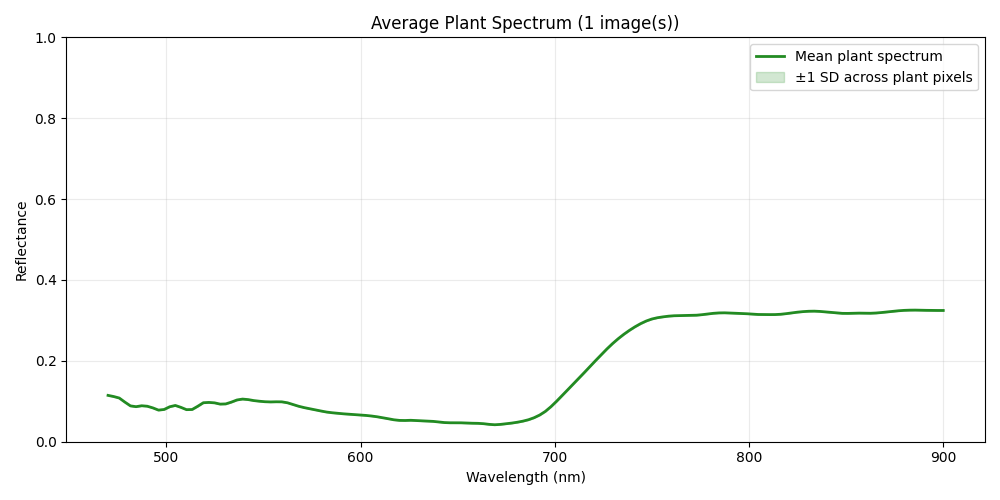

In [19]:

if not results:
    print("No results to plot.")
else:
    spectra_stack = np.vstack([r["avg_spectra"] for r in results])
    mean_spectrum = np.mean(spectra_stack, axis=0)
    std_spectrum  = np.std(spectra_stack, axis=0)

    # Clip to valid reflectance range — noisy edge bands can produce inf/nan
    mean_spectrum = np.clip(mean_spectrum, 0.0, 1.0)
    std_spectrum  = np.clip(std_spectrum,  0.0, 1.0)

    x = np.arange(mean_spectrum.shape[0])
    x_label = "Band index"
    if wavelengths_nm is not None and len(wavelengths_nm) == mean_spectrum.shape[0]:
        x = wavelengths_nm
        x_label = "Wavelength (nm)"

    sd_label = "±1 SD across images" if len(results) > 1 else "±1 SD across plant pixels"

    plt.figure(figsize=(10, 5))
    plt.plot(x, mean_spectrum, color="forestgreen", linewidth=2, label="Mean plant spectrum")
    plt.fill_between(
        x,
        np.clip(mean_spectrum - std_spectrum, 0.0, 1.0),
        np.clip(mean_spectrum + std_spectrum, 0.0, 1.0),
        color="forestgreen", alpha=0.2, label=sd_label,
    )
    plt.ylim(0.0, 1.0)
    plt.title(f"Average Plant Spectrum ({len(results)} image(s))")
    plt.xlabel(x_label)
    plt.ylabel("Reflectance")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()
